# DSA 4060 Recommender Systems — Week 1 Practical
## Build and Publish a Popularity Based Movie Recommender

| | |
|---|---|
| **Course** | DSA 4060 Recommender Systems |
| **Name** | Justice Chawanda |
| **Student number** | 670444 |
| **Date** | 20 September 2026 |
| **Dataset** | MovieLens `ml-latest-small` (GroupLens) |

### Purpose

This notebook builds two **non-personalized** movie recommendation baselines from the MovieLens
user-item ratings data: a *minimum-rating popularity* baseline and a *weighted-rating* baseline.
Every user receives the same ranked list, so the result is a transparent reference point that the
personalized models built later in the course can be compared against.

The notebook works through the problem in the order set out in the practical: inspect and validate
the data, explore the user-item interactions, rank movies two different ways, visualize and test the
output, and interpret what the recommendations do and do not achieve.

---
## Part 1 — Understand the Recommendation Problem

### 1.1 Core concepts

| Concept | Meaning in this practical |
|---|---|
| **User** | A person represented by `userId` who rates movies. |
| **Item** | A movie represented by `movieId`. |
| **Interaction** | A rating given by a user to a movie — one row of `ratings.csv`. |
| **Explicit feedback** | A directly stated preference: here, a star rating from 0.5 to 5.0. |
| **Recommendation** | A ranked list of items selected for a user or an audience. |
| **Baseline** | A simple method used as a reference when evaluating more advanced models. |

### 1.2 Business scenario

A new movie-streaming service does not yet know enough about each visitor to personalize its home
page. It needs a reliable list of widely liked movies to show everybody. A movie should not rank
first merely because one person gave it five stars, so the ranking method has to consider both **how
highly a movie is rated** and **how many people rated it**.

### 1.3 Questions this notebook answers

1. Which movies have received the most ratings?
2. Which movies have the highest average ratings?
3. Why can average rating alone be misleading?
4. How can rating volume and rating quality be combined?
5. What limitations does one shared Top 10 list have?

### 1.4 Expected data flow

`ratings.csv` supplies the user-item interactions and `movies.csv` supplies titles and genres. The
notebook validates both files, summarizes the ratings, aggregates results by movie, joins the movie
titles onto those aggregates, ranks the candidates, and displays the recommendations.

---
## Part 3 — Load and Inspect the Data

### 3.1 Import libraries

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

### 3.2 Define file paths

The notebook lives inside `notebooks/`, so `..` moves up to the project root. Paths are kept
relative so that the notebook runs on any machine after cloning the repository. If you run this in
Google Colab, replace `PROJECT_ROOT` with the location where you uploaded the CSV files.

In [2]:
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
IMAGES_DIR = PROJECT_ROOT / 'images'
IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / 'movies.csv'
RATINGS_FILE = DATA_DIR / 'ratings.csv'

### 3.3 Load the CSV files

In [3]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


### 3.4 Preview and inspect

In [4]:
display(movies.head())
display(ratings.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
print(movies.info())
print(ratings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


**Interpretation.** `movies.csv` holds 9,742 rows with the three expected columns `movieId`,
`title` and `genres`; `ratings.csv` holds 100,836 rows with `userId`, `movieId`, `rating` and
`timestamp`. Genres arrive as a single pipe-delimited string per movie rather than as separate
columns, and `timestamp` is stored as a Unix epoch integer rather than a datetime. Neither is a
problem for this week's work, but both would need converting for a content-based or
time-aware model.

Row counts can change if GroupLens updates `ml-latest-small`, so the counts recorded throughout this
notebook are those of the copy downloaded for this practical (the version dated September 2018).

### 3.5 Validate the data

Before ranking anything, check that the files are internally consistent: no missing fields, no
unexpected duplicate rows, ratings inside the documented 0.5–5.0 scale, and no ratings pointing at
movies that are absent from `movies.csv`.

In [6]:
print('Missing values in movies:')
print(movies.isna().sum())
print()
print('Missing values in ratings:')
print(ratings.isna().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [7]:
print('Duplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())
print('Rating range:', ratings['rating'].min(), 'to', ratings['rating'].max())
print('Unknown movie IDs:', (~ratings['movieId'].isin(movies['movieId'])).sum())

Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


A fully duplicated row is not the only kind of duplication that matters. The field combination that
*should* uniquely identify a record here is `(userId, movieId)` — one user is expected to hold one
current rating per movie — so that pair is checked separately below.

In [8]:
print('Duplicate (userId, movieId) pairs:',
      ratings.duplicated(subset=['userId', 'movieId']).sum())
print('Duplicate movieId values in movies:',
      movies['movieId'].duplicated().sum())

Duplicate (userId, movieId) pairs: 0
Duplicate movieId values in movies: 0


**Interpretation.** The data is clean on every check: no missing values in either file, no duplicate
rows, no repeated `(userId, movieId)` pairs, and no rating referring to a `movieId` that is missing
from `movies.csv`. Ratings fall within the documented 0.5–5.0 range, so no out-of-scale values need
handling.

Note that no rows were dropped here, and none should be. A non-zero duplicate count is not on its
own a reason to delete data — the right response is first to decide which fields are supposed to
identify a record uniquely. Repeated ratings by the same user for the same movie could legitimately
represent rating history in a dataset that keeps one row per rating *event*, in which case deleting
them would destroy information rather than clean it. In this dataset the check returns zero, so the
question is settled without any intervention.

### 3.6 Summarize the interaction data

In [9]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
n_interactions = len(ratings)

print('Unique users:', n_users)
print('Movies with at least one rating:', n_movies_rated)
print('Total rating interactions:', n_interactions)
print()
print(ratings['rating'].describe())

Unique users: 610
Movies with at least one rating: 9724
Total rating interactions: 100836

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [10]:
n_movies_catalogue = movies['movieId'].nunique()

print('Movies in the catalogue (movies.csv):', n_movies_catalogue)
print('Movies with at least one rating   :', n_movies_rated)
print('Movies with no ratings at all     :', n_movies_catalogue - n_movies_rated)

Movies in the catalogue (movies.csv): 9742
Movies with at least one rating   : 9724
Movies with no ratings at all     : 18


**What each number represents.**

- **610 unique users** — the number of distinct people in the dataset. It is the *user* dimension of
  the user-item matrix.
- **9,724 movies with at least one rating** — the *item* dimension of the matrix as it can actually
  be observed.
- **100,836 total interactions** — the number of filled cells: one row per (user, movie) rating.
- **Mean rating ≈ 3.50, median 3.5, range 0.5–5.0** — ratings sit well above the midpoint of the
  scale, so the average user rating is mildly positive rather than neutral.

The distinction between the last two counts in the second cell matters for the rest of the
practical. The catalogue contains **9,742** movies, but only **9,724** of them have ever been rated
— **18 movies carry no ratings at all**. Those 18 are invisible to every method in this notebook:
a popularity ranking built from ratings can never surface an item that has no ratings to aggregate.
That is the *cold-start problem* appearing in the dataset, before any model has been built.

---
## Part 4 — Explore User-Item Interactions

### 4.1 Ratings per user and per movie

In [11]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print('Ratings per user:')
print(ratings_per_user.describe())
print()
print('Ratings per movie:')
print(ratings_per_movie.describe())

Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


**Interpretation.** Both distributions are strongly right-skewed, and in opposite corners of the
same matrix.

Every user has rated at least 20 movies (GroupLens filters the dataset that way), but the median
user has rated 70 and the mean is 165 — pulled upward by a small number of extremely active users,
the largest of whom has rated 2,698 movies. A handful of users therefore contribute a
disproportionate share of all the ratings in the data.

Movies are skewed far harder. The median movie has just **3** ratings and the 25th percentile is
**1**, while the most-rated movie has 329. So the typical movie in this catalogue carries almost no
evidence about its quality. This single fact is the reason a raw average rating cannot be used to
rank movies, and it motivates both ranking methods built in Parts 5 and 6.

### 4.2 Examine the rating distribution

In [12]:
rating_distribution = ratings['rating'].value_counts().sort_index()
print(rating_distribution)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


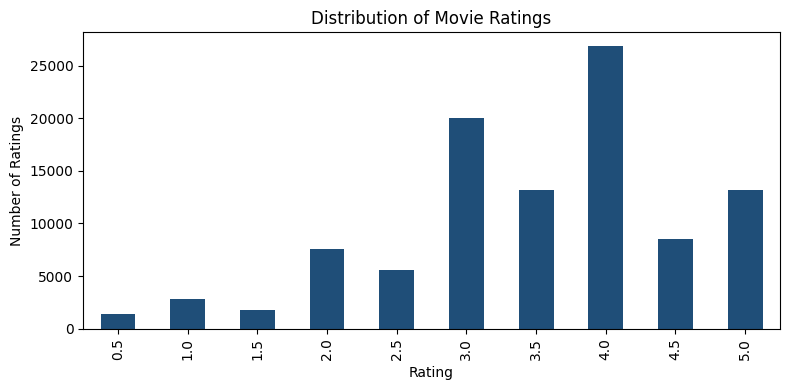

In [13]:
ax = rating_distribution.plot(kind='bar', color='#1F4E78', figsize=(8, 4))
ax.set_title('Distribution of Movie Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation.** The most frequent rating is **4.0**, given 26,818 times, followed by 3.0
(20,047) and 5.0 (13,211). The distribution leans clearly toward the upper half of the scale: the
four highest values (3.5 to 5.0) account for roughly 61% of all ratings, while the lowest value, 0.5,
is the rarest of all at 1,370 ratings.

Two further patterns are visible. Whole-star ratings are consistently more common than the half-star
value just below them — 3.0 outnumbers 2.5, 4.0 outnumbers 3.5, 5.0 outnumbers 4.5 — which suggests
users gravitate to whole numbers when the interface offers halves. And low ratings are genuinely
rare: 0.5, 1.0 and 1.5 together make up under 6% of the data.

The chart establishes *that* the distribution is skewed high; it does not establish *why*. Users
choosing to watch films they expect to enjoy, choosing to rate only films they felt something about,
or a general reluctance to award the lowest score would all produce a shape like this, and nothing
here distinguishes between them.

### 4.3 Calculate interaction matrix sparsity

A complete user-item matrix would hold one cell for every possible user-movie pair. Most cells are
normally empty, because each user rates only a small subset of the catalogue.

In [14]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)

print(f'Possible interactions: {possible_interactions:,}')
print(f'Observed interactions: {observed_interactions:,}')
print(f'Sparsity: {sparsity:.2%}')

Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


**Interpretation.** The full matrix would hold 610 × 9,724 = **5,931,640** cells, but only
**100,836** are filled. Sparsity is **98.30%**, meaning that roughly 98 of every 100 cells are
empty: on average a user has rated about 1.7% of the movies available to them.

High sparsity is the central practical difficulty in recommender systems. Any method that wants to
predict whether user *u* would enjoy movie *i* is almost always reasoning about a cell it has never
observed, and it must do so by borrowing evidence — from similar users, from similar items, or from
the population as a whole.

This week's popularity baseline does not attempt to fill those empty cells at all. It sidesteps
sparsity by ignoring the user dimension entirely and collapsing the matrix down its columns into one
score per movie. That is why it is robust and cheap, and equally why it cannot personalize.

---
## Part 5 — Build a Popularity Recommender

### 5.1 Aggregate ratings by movie

In [15]:
movie_stats = (
    ratings.groupby('movieId')
    .agg(average_rating=('rating', 'mean'),
         rating_count=('rating', 'count'))
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[['movieId', 'title', 'genres']],
    on='movieId',
    how='left',
    validate='one_to_one'
)

display(movie_stats.head())
print('movie_stats shape:', movie_stats.shape)

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


movie_stats shape: (9724, 5)


The `groupby` collapses 100,836 rating rows into one row per movie holding its mean rating and its
rating count; the merge attaches the readable title and genres. `validate='one_to_one'` makes the
merge *fail loudly* if either side contains an unexpected duplicate `movieId`, which is far safer
than silently multiplying rows and inflating every count downstream.

### 5.2 Most rated movies

In [16]:
most_rated = (
    movie_stats.sort_values(
        ['rating_count', 'average_rating'],
        ascending=[False, False]
    )
    .head(10)
)

display(most_rated[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


**Interpretation.** This list measures **visibility and engagement, not quality**. *Forrest Gump
(1994)* leads with 329 ratings and an average of 4.16; *The Shawshank Redemption (1994)* is second
with 317 ratings but a higher average of 4.43. Further down, *Jurassic Park (1993)* has 238 ratings
at an average of just 3.75 — widely watched and widely rated, but only moderately liked.

Ranking by count alone would therefore put a merely famous film above a better-loved one. The list is
also visibly dominated by 1990s mainstream releases, which is the first sign of the popularity bias
discussed in Part 8.

### 5.3 Highest average ratings

In [17]:
highest_average = (
    movie_stats.sort_values(
        ['average_rating', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(highest_average[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


In [18]:
print('Movies with a perfect 5.0 average:', (movie_stats['average_rating'] == 5.0).sum())
print('Movies rated exactly once        :', (movie_stats['rating_count'] == 1).sum(),
      f"({(movie_stats['rating_count'] == 1).mean():.1%} of rated movies)")

Movies with a perfect 5.0 average: 296
Movies rated exactly once        : 3446 (35.4% of rated movies)


**Interpretation — this is the key failure to understand.** Every title in this Top 10 has a perfect
5.0 average, and every one of them was rated **once or twice**. The supporting cell shows the scale
of the problem: **296 movies** hold a perfect 5.0 average, and **3,446 movies — 35.4% of the
catalogue — have been rated exactly once**. Any movie rated once by a generous user achieves a flawless
score.

A 5.0 average from two ratings and a 4.43 average from 317 ratings are not comparable quantities.
The first is an accident of who happened to watch the film; the second is a stable estimate. This is
why average rating alone is a weak popularity baseline, and it is precisely what the next two
sections correct — Section 5.4 by *excluding* thin evidence, Part 6 by *discounting* it.

### 5.4 Minimum ratings baseline

Require a movie to have at least 50 ratings before it is eligible to be ranked by average rating.
The threshold of 50 is a **teaching choice, not a universal rule** — Section 7.3 tests how the
output changes when it moves, and Part 6 replaces it with a value derived from the dataset itself.

In [19]:
MIN_RATINGS = 50

popular_movies = (
    movie_stats[movie_stats['rating_count'] >= MIN_RATINGS]
    .sort_values(
        ['average_rating', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(popular_movies[['title', 'genres', 'rating_count', 'average_rating']])
print('Movies qualifying with >= 50 ratings:',
      (movie_stats['rating_count'] >= MIN_RATINGS).sum())

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


Movies qualifying with >= 50 ratings: 450


**Interpretation.** The threshold transforms the list. The 5.0-average curiosities are gone, and the
ranking is now headed by *The Shawshank Redemption (1994)* at 4.43 from 317 ratings — a film with
both a high average *and* enough evidence to trust it. It is followed by *The Godfather (1972)*
(4.29, 192 ratings) and *Fight Club (1999)* (4.27, 218 ratings).

The cost of the rule is severe: only **450 of 9,724 rated movies** clear 50 ratings, so the
threshold discards **95.4%** of the catalogue outright. It also still ranks purely on average within
the survivors, which is why *Cool Hand Luke (1967)* at 4.27 from 57 ratings sits above
*Casablanca (1942)* at 4.24 from 100 — a difference of 0.03 stars separating a thin estimate from a
much firmer one. The threshold is a blunt instrument: inside the cutoff, evidence still counts for
nothing.

### 5.5 Convert the logic into a function

Wrapping the logic in a function makes the thresholds explicit parameters, so the baseline can be
re-run under different policies (Section 7.3) and reused by the genre filter (Section 7.4).

In [20]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    """Return the top_n movies by average rating among those with >= min_ratings ratings.

    Parameters
    ----------
    stats : DataFrame with columns movieId, title, genres, rating_count, average_rating
    min_ratings : minimum number of ratings a movie needs to be eligible
    top_n : number of recommendations to return

    Returns
    -------
    DataFrame of at most top_n rows, ranked by average rating then rating count.
    """
    candidates = stats[stats['rating_count'] >= min_ratings].copy()
    return (
        candidates.sort_values(
            ['average_rating', 'rating_count'],
            ascending=[False, False]
        )
        .head(top_n)
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating']]
    )


recommendations = recommend_popular_movies(movie_stats, 50, 10)
display(recommendations)

,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


---
## Part 6 — Build a Weighted Rating Baseline

### 6.1 Why use a weighted score

A minimum threshold is all-or-nothing: it throws away every movie below the cutoff, and then treats
every movie above it as equally trustworthy. A weighted rating handles the same problem
proportionally — it pulls the estimate for a thinly-rated movie *toward the overall mean*, while a
movie with many ratings is allowed to be judged mostly on its own average.

$$\text{weighted score} = \frac{v}{v + m} \cdot R \;+\; \frac{m}{v + m} \cdot C$$

| Symbol | Meaning |
|---|---|
| $R$ | the movie's own average rating |
| $v$ | the movie's rating count |
| $C$ | the overall mean rating across all ratings |
| $m$ | the minimum evidence threshold |

The two fractions are weights that always sum to 1. When $v$ is small relative to $m$, most of the
weight sits on $C$ and the score is dragged toward the population average. As $v$ grows past $m$,
the weight shifts onto $R$ and the movie is judged on its own merits. A movie with $v = m$ lands
exactly halfway between the two.

### 6.2 Select the threshold

Rather than picking $m$ by hand, derive it from the data: use the 90th percentile of the rating
count, so that only movies in roughly the top 10% by rating volume qualify.

In [21]:
C = ratings['rating'].mean()
m = movie_stats['rating_count'].quantile(0.90)

print(f'Overall mean rating C: {C:.3f}')
print(f'90th percentile rating count m: {m:.1f}')
print('Movies qualifying (rating_count >= m):', (movie_stats['rating_count'] >= m).sum())

Overall mean rating C: 3.502
90th percentile rating count m: 27.0
Movies qualifying (rating_count >= m): 976


In [22]:
# How would a different percentile change the candidate pool?
for percentile in [0.80, 0.90, 0.95, 0.99]:
    threshold = movie_stats['rating_count'].quantile(percentile)
    qualifying = (movie_stats['rating_count'] >= threshold).sum()
    print(f'{percentile:.0%} percentile -> m = {threshold:5.1f} '
          f'-> {qualifying:5,} movies qualify '
          f'({qualifying / len(movie_stats):.1%} of rated movies)')

80% percentile -> m =  12.0 -> 1,967 movies qualify (20.2% of rated movies)
90% percentile -> m =  27.0 ->   976 movies qualify (10.0% of rated movies)
95% percentile -> m =  47.0 ->   491 movies qualify (5.0% of rated movies)
99% percentile -> m = 114.5 ->    98 movies qualify (1.0% of rated movies)


**Interpretation.** The overall mean rating is **C = 3.502** and the 90th-percentile rating count is
**m = 27.0**, leaving **976 qualifying movies** — more than twice the 450 admitted by the fixed
50-rating rule, so this policy is the more *inclusive* of the two at the gate while being the more
*conservative* about what it does with thin evidence once inside.

The percentile sweep shows how much the choice matters. Dropping to the 80th percentile sets m = 12
and admits 1,967 movies, roughly double the pool, but it also lowers the bar to which thin averages
are anchored. Raising it to the 95th sets m = 47 and admits 491 — close to the fixed threshold's
pool, with a much stronger pull toward C. The 99th percentile leaves only a small set of blockbusters.

Note that m does double duty in this formula: it is both the *eligibility gate* and the *strength of
the shrinkage*. Raising it shrinks the candidate pool and simultaneously pulls the survivors harder
toward the mean. This is a transparent policy choice, not a statistically optimal one.

### 6.3 Calculate weighted scores

In [23]:
qualified = movie_stats[movie_stats['rating_count'] >= m].copy()

v = qualified['rating_count']
R = qualified['average_rating']

qualified['weighted_score'] = (
    (v / (v + m)) * R +
    (m / (v + m)) * C
)

weighted_recommendations = (
    qualified.sort_values(
        ['weighted_score', 'rating_count'],
        ascending=[False, False]
    )
    .head(10)
)

display(weighted_recommendations[[
    'title', 'genres', 'rating_count',
    'average_rating', 'weighted_score'
]])

,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


**Interpretation.** *The Shawshank Redemption (1994)* ranks first again, with a weighted score of
**4.356** — shrunk from its raw average of 4.429 because even 317 ratings carry a little pull toward
C. Notice how the size of that shrinkage tracks the evidence: Shawshank loses 0.073 with 317
ratings, while *The Godfather: Part II (1974)* loses 0.131 with 129. Every score is pulled down
toward 3.502, but a movie is pulled down *less* the more ratings support it.

The effect is that rating count now contributes to the ranking continuously instead of through a
pass/fail gate. *Star Wars: Episode IV (1977)* ranks 4th on a weighted score of 4.160 despite a raw
average (4.231) lower than several movies it outranks, because its 251 ratings make that average far
harder to dismiss.

### 6.4 Compare the two lists

In [24]:
comparison = popular_movies[['title', 'rating_count', 'average_rating']].copy()
comparison['method'] = 'Minimum 50 ratings'

weighted_view = weighted_recommendations[[
    'title', 'rating_count', 'average_rating'
]].copy()
weighted_view['method'] = 'Weighted score'

display(pd.concat([comparison, weighted_view], ignore_index=True))

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


In [25]:
in_both = set(popular_movies['title']) & set(weighted_recommendations['title'])
only_threshold = set(popular_movies['title']) - set(weighted_recommendations['title'])
only_weighted = set(weighted_recommendations['title']) - set(popular_movies['title'])

print(f'Titles in BOTH lists ({len(in_both)}):')
for title in sorted(in_both):
    print('   ', title)
print(f'\nOnly in the minimum-50 list ({len(only_threshold)}):')
for title in sorted(only_threshold):
    print('   ', title)
print(f'\nOnly in the weighted list ({len(only_weighted)}):')
for title in sorted(only_weighted):
    print('   ', title)

Titles in BOTH lists (4):
    Fight Club (1999)
    Godfather, The (1972)
    Godfather: Part II, The (1974)
    Shawshank Redemption, The (1994)

Only in the minimum-50 list (6):
    Casablanca (1942)
    Cool Hand Luke (1967)
    Departed, The (2006)
    Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)
    Goodfellas (1990)
    Rear Window (1954)

Only in the weighted list (6):
    Matrix, The (1999)
    Pulp Fiction (1994)
    Schindler's List (1993)
    Star Wars: Episode IV - A New Hope (1977)
    Star Wars: Episode V - The Empire Strikes Back (1980)
    Usual Suspects, The (1995)


In [26]:
print('Median rating count, minimum-50 list :',
      int(popular_movies['rating_count'].median()))
print('Median rating count, weighted list   :',
      int(weighted_recommendations['rating_count'].median()))

Median rating count, minimum-50 list : 116
Median rating count, weighted list   : 219


**Comparison.** Only **4 of 10** titles appear in both lists: *The Shawshank Redemption*,
*The Godfather*, *The Godfather: Part II* and *Fight Club*. These four are the films that are both
highly rated and heavily rated, so they survive either policy — a reasonable definition of a robust
recommendation.

The six titles unique to each list reveal what each method rewards. The minimum-50 list keeps
*Cool Hand Luke* (57 ratings), *Rear Window* (84) and *Dr. Strangelove* (97) — films sitting just
past the cutoff whose high averages rest on modest evidence. The weighted list replaces them with
*Star Wars: Episode IV* (251), *Pulp Fiction* (307) and *The Matrix* (278) — lower raw averages,
much heavier support.

**Which method is more conservative about small rating counts?** The weighted score, unambiguously.
Its median recommended movie carries 219 ratings against 113 for the threshold list, and no film in
its Top 10 has fewer than 129. It never lets a thin average win, whereas the threshold rule waves
through anything at 50 ratings and then ignores evidence entirely.

**What neither method achieves.** Both lists are identical for every visitor — neither is
personalized. Both are dominated by acclaimed 1990s and 1970s drama and crime films, so neither
offers genre diversity, and neither surfaces anything a film-aware user would find novel. Neither
can recommend a new release at all.

---
## Part 7 — Visualize and Test the Output

### 7.1 Create a Top 10 chart

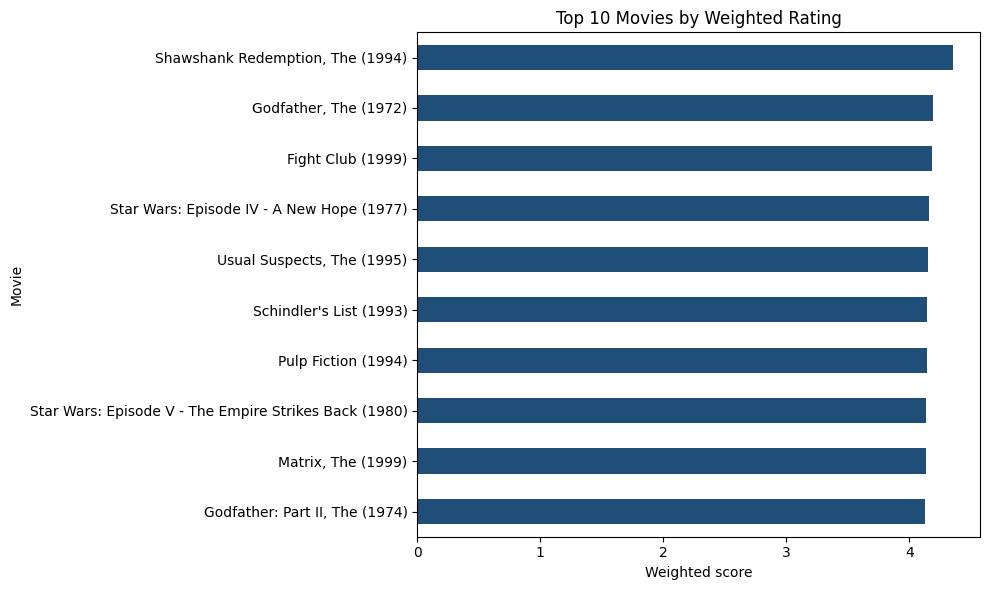

In [27]:
plot_data = weighted_recommendations.sort_values('weighted_score')

ax = plot_data.plot(
    x='title',
    y='weighted_score',
    kind='barh',
    figsize=(10, 6),
    color='#1F4E78',
    legend=False
)
ax.set_title('Top 10 Movies by Weighted Rating')
ax.set_xlabel('Weighted score')
ax.set_ylabel('Movie')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

The bars are plotted in ascending order so that the highest-scoring movie appears at the top of the
horizontal chart. Note how compressed the scale is — the ten scores span roughly 4.13 to 4.36, a
range of about 0.23 stars. The ranking positions are therefore much less meaningful than the fact of
membership in the Top 10; small changes to m would reshuffle the middle of this list without saying
anything substantive about the films.

### 7.2 Perform basic tests

These assertions check the *structural* contract of the recommender: the right number of rows,
unique items, thresholds actually enforced, ratings inside the valid scale, and no missing titles or
scores.

In [28]:
assert len(recommendations) <= 10
assert recommendations['movieId'].is_unique
assert recommendations['rating_count'].ge(50).all()
assert recommendations['average_rating'].between(0.5, 5.0).all()
assert recommendations['title'].notna().all()

assert len(weighted_recommendations) <= 10
assert weighted_recommendations['weighted_score'].notna().all()

print('All checks passed.')

All checks passed.


In [29]:
# A few additional checks on the weighted baseline specifically.
assert weighted_recommendations['movieId'].is_unique
assert weighted_recommendations['rating_count'].ge(m).all()
assert weighted_recommendations['weighted_score'].between(0.5, 5.0).all()

# The weighted score must always lie between the movie's own average and the overall mean C.
lower = qualified[['average_rating']].assign(C=C).min(axis=1)
upper = qualified[['average_rating']].assign(C=C).max(axis=1)
assert (qualified['weighted_score'] >= lower - 1e-9).all()
assert (qualified['weighted_score'] <= upper + 1e-9).all()

# The ranking must actually be sorted.
assert weighted_recommendations['weighted_score'].is_monotonic_decreasing

print('All weighted-baseline checks passed.')

All weighted-baseline checks passed.

**What these tests do and do not establish.** They confirm that the code does what it claims: the
output has the requested shape, contains no duplicate movies, respects its own thresholds, and
produces scores that are mathematically coherent (in particular, every weighted score falls between
the movie's own average and the overall mean, as the formula requires).

They prove nothing about whether the recommendations are *useful*. No assertion can tell whether a
list of acclaimed 1990s dramas serves a given visitor, whether the list is too narrow, or whether it
should include a recent release. Structural tests catch broken code; human review and, later, proper
offline evaluation against held-out data are what assess recommendation quality.

### 7.3 Try different parameters

In [30]:
print('--- min_ratings = 20 ---')
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5))

print('--- min_ratings = 100 ---')
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))

--- min_ratings = 20 ---


,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


--- min_ratings = 100 ---


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


In [31]:
for threshold in [20, 50, 100, 200]:
    qualifying = (movie_stats['rating_count'] >= threshold).sum()
    print(f'min_ratings = {threshold:3d} -> {qualifying:5,} movies qualify '
          f'({qualifying / len(movie_stats):5.1%} of rated movies)')

min_ratings =  20 -> 1,297 movies qualify (13.3% of rated movies)
min_ratings =  50 ->   450 movies qualify ( 4.6% of rated movies)
min_ratings = 100 ->   138 movies qualify ( 1.4% of rated movies)
min_ratings = 200 ->    19 movies qualify ( 0.2% of rated movies)


**Interpretation.** Lowering the threshold to 20 admits 1,297 movies and immediately lets
*A Streetcar Named Desire (1951)* take first place on an average of 4.475 from exactly **20**
ratings — beating Shawshank's 4.429 from 317. That ranking is unstable: one additional 3-star rating
would drop it below Shawshank. A low threshold admits more of the catalogue but makes the top of the
list hostage to small samples.

Raising it to 100 leaves only 138 movies (1.4% of the catalogue) and yields a top 5 of Shawshank,
*The Godfather*, *Fight Club*, *The Godfather: Part II* and *The Departed* — heavily-rated films
whose positions barely move regardless of the exact cutoff. The rankings are stable, but the method
now recommends only from a pool of very widely seen films, excluding less-known high-quality items
entirely. This is popularity bias introduced directly by a parameter choice.

The trade-off is unavoidable for a hard threshold, and it is exactly what the weighted score is
designed to soften: instead of choosing where to cut, it lets every movie's influence scale with its
own evidence.

### 7.4 Optional genre filter

In [32]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
    """Top-N popular movies restricted to those whose genres field contains `genre`."""
    mask = stats['genres'].str.contains(genre, case=False, na=False)
    return recommend_popular_movies(stats[mask], min_ratings, top_n)


display(recommend_by_genre(movie_stats, 'Comedy', 30, 10))

,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


In [33]:
for genre in ['Comedy', 'Horror', 'Documentary', 'Children']:
    top = recommend_by_genre(movie_stats, genre, 30, 1)
    if len(top):
        row = top.iloc[0]
        print(f"{genre:12s} -> {row['title']} "
              f"({row['average_rating']:.2f} from {row['rating_count']} ratings)")
    else:
        print(f'{genre:12s} -> no movie meets the threshold')

Comedy       -> Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964) (4.27 from 97 ratings)


Horror       -> Rosemary's Baby (1968) (4.17 from 32 ratings)
Documentary  -> Roger & Me (1989) (3.84 from 31 ratings)
Children     -> Toy Story 3 (2010) (4.11 from 55 ratings)


**Interpretation.** The genre filter is a useful piece of product surface — it gives the home page
several shelves instead of one — but it is **still not personalization**. Every visitor who asks for
Comedy receives the identical list. It is a contextual filter applied to a population ranking, not a
learned model of anybody's preferences.

The per-genre sweep also shows the threshold interacting badly with smaller genres: genres with few
heavily-rated titles produce short or empty lists at the same cutoff that works for Comedy, so a
production system would need a per-genre threshold or a shrinkage approach rather than one global
number.

One caveat on the implementation: `str.contains` does a substring match on the pipe-delimited genres
string, so searching for `'Children'` would also match a genre named `'Children's'`, and short
search terms risk matching inside other genre names. Splitting the genres field into a proper list
would be the robust fix, and would be a prerequisite for the content-based model suggested below.

---
## Part 8 — Interpret the Results

### 8.1 Questions for the notebook

The cell below recomputes each answer directly from the data rather than restating numbers by hand,
so the answers stay correct if the dataset is updated.

In [34]:
top_rated_movie = most_rated.iloc[0]
threshold_first = popular_movies.iloc[0]
weighted_first = weighted_recommendations.iloc[0]
n_qualified = (movie_stats['rating_count'] >= m).sum()

print('1. Most-rated movie:')
print(f"      {top_rated_movie['title']} - {top_rated_movie['rating_count']} ratings, "
      f"average {top_rated_movie['average_rating']:.3f}")

print('\n2. First after the 50-rating threshold:')
print(f"      {threshold_first['title']} - average {threshold_first['average_rating']:.3f} "
      f"from {threshold_first['rating_count']} ratings")

print('\n3. First by weighted score:')
print(f"      {weighted_first['title']} - weighted {weighted_first['weighted_score']:.3f} "
      f"(raw average {weighted_first['average_rating']:.3f} from "
      f"{weighted_first['rating_count']} ratings)")

print('\n4. Movies qualifying under the 90th-percentile threshold:')
print(f"      {n_qualified:,} of {len(movie_stats):,} rated movies "
      f"({n_qualified / len(movie_stats):.1%})")

1. Most-rated movie:
      Forrest Gump (1994) - 329 ratings, average 4.164

2. First after the 50-rating threshold:
      Shawshank Redemption, The (1994) - average 4.429 from 317 ratings

3. First by weighted score:
      Shawshank Redemption, The (1994) - weighted 4.356 (raw average 4.429 from 317 ratings)

4. Movies qualifying under the 90th-percentile threshold:
      976 of 9,724 rated movies (10.0%)


**1. Which movie received the most ratings, and what was its average rating?**
*Forrest Gump (1994)*, with **329 ratings** and an average of **4.164**. It is the most-rated film
but not the highest-rated: *The Shawshank Redemption* has 12 fewer ratings and a materially higher
average of 4.429.

**2. Which movie ranked first after applying the 50-rating threshold?**
*The Shawshank Redemption (1994)*, average **4.429** from **317 ratings**.

**3. Which movie ranked first using the weighted score?**
*The Shawshank Redemption (1994)* again, weighted score **4.356**. Its raw average of 4.429 is
shrunk slightly toward C = 3.502. That the same film tops both lists is reassuring: it wins on
average rating *and* on volume, so no reasonable weighting of the two dislodges it.

**4. How many movies qualified under the 90th-percentile threshold?**
**976 movies** of the 9,724 with at least one rating — 10.0% by construction, since m = 27 is the
90th percentile of the rating-count distribution.

**5. What changed when the minimum rating threshold was increased?**
The candidate pool shrank sharply (1,297 movies at 20 → 450 at 50 → 138 at 100) and the rankings
became more stable and more mainstream. At 20 ratings, *A Streetcar Named Desire* takes first place
on 20 ratings, a position one extra rating could overturn. At 100, the list settles into
heavily-rated canonical films that barely move as the cutoff changes. Stability is bought by
excluding less-known items — a direct trade of coverage for reliability.

**6. Why is the resulting list not personalized?**
Because the user dimension is discarded at the very first step. `groupby('movieId')` collapses all
100,836 interactions into one row per movie, aggregating across every user. Nothing downstream
consults `userId`, so the function has no input that varies by person and every visitor receives an
identical list by construction. A personalized system would need the individual user's ratings as an
input to the ranking.

**7. What bias may result from recommending only already-popular movies?**
Popularity bias, which compounds through a feedback loop. Showing widely-rated films on the home
page drives more views, which produce more ratings, which push those same films further up the
ranking. The effect is visible in the data already: 35.4% of movies have exactly one rating and can
never compete, while the top 10% absorb the attention. Films from under-represented regions,
languages, genres and eras are systematically disadvantaged regardless of their quality, and the
catalogue's effective diversity shrinks over time.

**8. How could the system handle a new movie with no ratings?**
This is the item cold-start problem — and it is concrete here, since 18 catalogue movies have no
ratings at all and are unreachable by any method in this notebook. Practical options include:
using content features (genres, cast, director, synopsis text) to rank a new title by similarity to
films that are known to perform well; falling back to the overall mean C, which is exactly what the
weighted formula does as v → 0; deliberately reserving a slice of home-page slots for exploration,
accepting a short-term cost to gather the ratings that make a proper estimate possible; or using
editorial or business rules until a minimum evidence level is reached.

### 8.2 Findings and Limitations

#### Findings

The MovieLens `ml-latest-small` dataset contains 100,836 ratings from 610 users across 9,742
catalogue movies, of which 9,724 have been rated at least once, collected between March 1996 and
September 2018. The data proved clean on every validation check — no missing values, no duplicate
rows, no repeated `(userId, movieId)` pairs, no out-of-range ratings and no ratings referencing
unknown movies — so no rows were removed, which is the right outcome: duplicates should be
investigated against a definition of record identity, not deleted on sight.

The dominant structural feature is extreme imbalance. The user-item matrix is **98.30% sparse**: of
5,931,640 possible cells only 100,836 are filled, so the average user has rated under 2% of the
catalogue. Both margins of that matrix are heavily skewed. The median user has rated 70 movies while
the most active has rated 2,698; far more consequentially, the median *movie* has only 3 ratings and
a quarter of rated movies have exactly one. Ratings themselves skew positive, centring on 4.0 with
an overall mean of 3.502, and low ratings are rare.

That skew is what makes raw average rating useless as a ranking signal. 296 movies hold a perfect
5.0 average, and 3,446 movies — 35.4% of those rated — were rated exactly once, so the unfiltered
"highest average" list consists entirely of films rated once or twice by a single enthusiastic
user. The two baselines are different corrections for the same problem. The **minimum-50 threshold**
excludes thin evidence, admitting 450 movies and ranking them purely on average. The **weighted
score** instead discounts thin evidence continuously, shrinking each movie's average toward the
overall mean in proportion to how few ratings support it, with m = 27 taken from the 90th percentile
of the rating count. The weighted approach is both more inclusive at the gate (976 candidates) and
more conservative in its output: its median recommendation carries 219 ratings against 113 for the
threshold list, and its Top 10 contains nothing with fewer than 129 ratings. Only four titles appear
in both lists — *Shawshank*, both *Godfather* films and *Fight Club* — and those four are the
recommendations that are robust to the choice of method.

#### Limitations

**1. No personalization.** The user dimension is discarded by the first `groupby`, so every visitor
receives an identical list. A user who watches only documentaries and a user who watches only horror
get the same ten crime and drama films. The system has no mechanism to be wrong about an individual,
because it never models one.

**2. Popularity bias and its feedback loop.** Both methods require substantial rating volume, which
only accrues to films that were already widely seen. Recommending them generates more views, more
ratings and a higher ranking, entrenching the same titles. The 35.4% of movies with one rating can
never enter the list, so the long tail is structurally unreachable and catalogue diversity narrows
over time.

**3. Cold start for new items.** A film with no ratings cannot be aggregated, ranked or recommended.
The 18 unrated catalogue movies here are invisible to every method in this notebook, and any genuinely
new release would be too — precisely the titles a streaming service most needs to promote.

**4. No handling of time.** Every rating is weighted equally whether it was given in 1996 or 2018,
despite the data spanning 22 years. Tastes shift, films are reappraised and recency matters to a home
page, yet `timestamp` is never used. The recommendations skew heavily toward 1970s–1990s films partly
as an artefact of when the ratings were collected.

**5. A rating does not explain itself.** A 4.5 records *that* a user approved, not *why* — the
direction, the performances, the soundtrack, or watching it with someone. Without that, the system
cannot generalize the reason to other films, which is the ceiling on what any purely
ratings-based method can learn.

**6. No evaluation against held-out data.** The assertions in Part 7 check structure, not quality.
Nothing here measures whether these lists would actually be clicked, and no train/test split was
made, so there is no evidence of predictive performance — only of internal consistency.

**7. Arbitrary policy parameters.** Both 50 and the 90th percentile are choices, not findings. As
Section 7.3 shows, moving the threshold materially changes the output, and nothing in the analysis
identifies a correct value. The rankings are also compressed into a 0.23-star band, so the ordering
within the Top 10 carries far less meaning than membership in it.

### 8.3 Recommended improvements

- **Content-based modelling.** Split the pipe-delimited `genres` field into proper features and add
  textual metadata, so that a new film can be ranked by similarity to known performers rather than
  waiting for ratings. This directly addresses limitations 2 and 3.
- **Collaborative filtering.** Use the user-rating patterns discarded here — user-user or item-item
  neighbourhoods, or matrix factorization — to predict the empty cells of the 98.30%-sparse matrix
  and give each user a different list.
- **Proper offline evaluation.** Split the ratings into training and test sets (ideally by timestamp
  rather than at random, to avoid using the future to predict the past) and measure ranking quality
  with precision@k, recall@k or NDCG against the Week 1 baseline established here.
- **Beyond-accuracy measures.** Track diversity, novelty and catalogue coverage alongside rating
  score. A list optimized purely for predicted rating will converge on the same popular titles; these
  measures are what make popularity bias visible and manageable.
- **Time and recency.** Use the `timestamp` column: weight recent ratings more heavily, and consider
  separating a film's long-run reputation from its current momentum.
- **Hybrid fallback.** Combine the approaches by serving this popularity baseline to anonymous or
  brand-new visitors and switching to a personalized model once a user has enough interactions —
  which keeps the baseline useful in production rather than discarding it.

---
## Reflection Questions

**1. What did the popularity baseline do well?**
It is transparent, cheap and hard to embarrass. Every number can be traced back to a `groupby`, it
needs no training and no tuning beyond one threshold, it runs instantly, and it works for a visitor
about whom absolutely nothing is known. Its Top 10 is a defensible answer to "what do people here
like?" — the four titles common to both methods are genuinely well-regarded films, not artefacts.

**2. Which users or movies might be disadvantaged by this approach?**
Users with tastes away from the mainstream are served worst: anyone who prefers documentaries,
horror, foreign-language or recent releases receives a list of 1970s–1990s English-language crime and
drama. On the item side, the 3,446 movies with a single rating and the 18 with none are structurally
unreachable, as is any new release — the films that most need exposure are the ones the method cannot
surface.

**3. What additional data would be needed to personalize recommendations?**
The per-user rating vectors that this notebook aggregates away are enough to start collaborative
filtering. Beyond that: item content features (genres, cast, director, synopsis) for content-based
similarity and cold-start coverage; implicit signals such as watches, completion rate, searches and
skips, which are far denser than explicit ratings; and session context — device, time of day, who is
watching — since preferences on a weekday commute differ from a Saturday evening.

**4. Which result would you use as the home-page baseline and why?**
The weighted-rating list. It handles the dataset's central problem — thin evidence — proportionally
rather than with a cliff edge, so nothing reaches the home page on the strength of 50-odd ratings; its
median recommendation carries roughly twice the evidence of the threshold list; and it degrades
gracefully toward the overall mean instead of failing when a movie is new. It needs one additional
safeguard before shipping: a diversity or genre-spread constraint, since left alone it returns ten
films from two adjacent genres.

**5. What will you change in the next version of the recommender?**
Add a proper train/test split by timestamp so that any subsequent model can be measured against this
baseline rather than merely compared to it by eye; split the genres field into usable features; and
build an item-item collaborative filter as the first genuinely personalized model. I would also
introduce a diversity measure at the same time as the first personalized model, so that improvements
in accuracy are not bought silently with narrower recommendations.

---

### Notebook complete

Both baselines are built, tested, visualized and interpreted. The Top 10 chart is saved to
`images/top10_recommendations.png` for inclusion in `README.md`.

**Dataset attribution.** F. Maxwell Harper and Joseph A. Konstan. 2015. *The MovieLens Datasets:
History and Context.* ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19.
<https://doi.org/10.1145/2827872>. Dataset: MovieLens `ml-latest-small`, GroupLens Research,
University of Minnesota, <https://grouplens.org/datasets/movielens/>, accessed 20 September 2026.